# Black-body radiation: Planck's Law, Rayleigh-Jeans Limit, and Wien's Displacement

This notebook implements the lab:

  1. A **single quantum mode** (harmonic oscillator) at thermal equilibrium: thermal state, $\langle n\rangle$, $\langle E\rangle$, and the photon number distribution **P(n)**.
  
  2. **Many modes** reconstruct the spectral shape and compare **Planck vs Rayleigh-Jeans**.
  
  3. Verification: agreement at low frequency, the classical divergence (UV catastrophe), and how the spectral maximum shifts with temperature (Wien).


In [65]:
# --- 0) Setup ---
# If QuTip is not installed in your environment, install with:
# !pip install qutip
import numpy as np
import matplotlib.pyplot as plt
from qutip import destroy, thermal_dm, expect, qeye
# Constantes (SI)
h = 6.62607015e-34         # J*s
hbar = h/(2*np.pi)         # J*s
kB = 1.380649e-23          # J*s
c = 299792458.0            # m/s
print("Imports OK, QuTiP ready.")

Imports OK, QuTiP ready.


## Saving figures  

You must have at leat **two figures** (PNG or PDF)

  1. The single mode $\textbf{P(n)}$ plot.

  2. The **Planck vs Rayleigh-Jeans** comparison.
  
In the code below, replace $\texttt{lastname}$ with your last name (or your prefer identifier).

## Theory: number states $(|n\rangle)$ and what P(n) means

For a single **electromagnetic field mode** (one frequency), a natural way to describe its quantum state is to use **number states**.

  - They are written as $|n\rangle$ and mean: "the mode contains exactly $n$ photons".
  
  - The integer $n$ can take values $0,1,2,...$
  
The **photon-number operator** is defined as:

  - $a_{op}=a^\dagger a$
  
and the only possible outcomes of a measurement are precisely $n=0,1,2,...$   

In this lab we will compute:

  - $\langle n \rangle$: the mean photon number in the termal state
  
  - **P(n)**: the probability of obtaining $n$ photons when measuring the photon number of the mode.
  
In the code **P(n)** is obtained from the **diagonal** of the density matrix $\rho_T$ written in the number basis $\{|n\rangle\}$.


In [66]:
# --- Mode parameters ---
N = 40                 # Fock-space dimension (truncation)
nu = 3e12              # frequency in Hz (example: THz)
omega = 2*np.pi*nu     # angular frequency
T = 300.0              # temperature in K  
# --- QuTiP operators ---
a = destroy(N)
adag = a.dag()
n_op = adag*a
# Hamiltonian (SI)
H = hbar*omega*(n_op + 0.5*qeye(N))
# --- Thermal state ---
nbar = 1/(np.exp(hbar*omega/(kB*T)) - 1.0)
rho_T = thermal_dm(N,nbar)
# --- Observables ---
n_mean = expect(n_op, rho_T)
E_mean = expect(H, rho_T)

In [67]:
# --- Impresión de resultados ---
print(f"Parameter: nu = {nu:.2e} Hz, T = {T:.1f} K, N = {N:.2e}")
print(f"nbar (theory): {nbar:.6f}")
print(f" <n> (QuTiP): {n_mean:.6f}")
print(f" <E> (QuTiP): {E_mean:.6e} J")

Parameter: nu = 3.00e+12 Hz, T = 300.0 K, N = 4.00e+01
nbar (theory): 1.623503
 <n> (QuTiP): 1.623503
 <E> (QuTiP): 4.221143e-21 J


In [68]:
# P(n) = diagonal of rho_T in the numebr basis
P_n = np.real(np.diag(rho_T.full()))
P_n = P_n/P_n.sum()

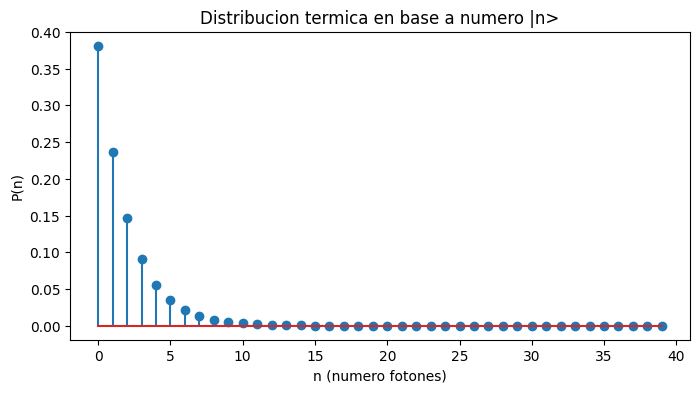

In [69]:
n = np.arange(len(P_n))
plt.figure(figsize=(8, 4))
plt.stem(n, P_n)
plt.xlabel("n (numero fotones)")
plt.ylabel("P(n)")
plt.title("Distribucion termica en base a numero |n>")
plt.show()

## 1.1) Classical limit (equipartition)

In the limit $h \,\ nu << kB\,\ T$, the thermal energy per mode approaches the classical result $kB\,\ T$. We explore $\equiv hbar\,\ omega\,\ nbar$ (without zero-point energy) and compare it with $kB\,\ T$.

In [70]:
T_test = 300.0
nus = np.logspace(10,14,80) #1e10 a 1e14 Hz
E_th = []
E_class = kB*T_test
for nu_i in nus:
  omega_i = 2*np.pi*nu_i
  nbar_i = 1.0/(np.exp(hbar*omega_i/(kB*T_test)) - 1.0)
  E_th.append(hbar*omega_i*nbar_i)
  
E_th = np.array(E_th)  

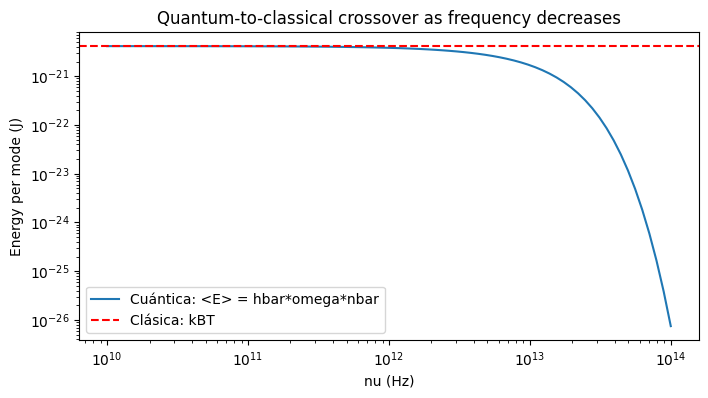

In [71]:
plt.figure(figsize=(8, 4))
plt.loglog(nus, E_th, label="Cuántica: <E> = hbar*omega*nbar")
plt.axhline(y=E_class, color='red', linestyle='--', label="Clásica: kBT")
plt.xlabel("nu (Hz)")
plt.ylabel("Energy per mode (J)")
plt.title("Quantum-to-classical crossover as frequency decreases")
plt.legend()
plt.show()

In [72]:
print("For sufficiently low nu, the quantum curve approaches kB*T.")

For sufficiently low nu, the quantum curve approaches kB*T.


## 2) Many modes: Planck vs Rayleigh-Jeans

We use:

  - nbar(nu,T) = 1 / (exp(h nu)/(kB T) - 1)
  
  - Ebar(nu,T) = h nu nbar(nu,T) (sin punto cero)
  
  - densidad de modos: g(nu) proporcional a nu^2
  
We construct: u_planck(nu) proporcional a g(nu)*Ebar(nu,T) u_RJ(nu) proporcional a g(nu) kB T


In [74]:
T_spec = 3000.0 # K
nu_min, nu_max = 1e11, 3e15
nu_grid = np.logspace(np.log10(nu_min), np.log10(nu_max), 600)
x = h*nu_grid/(kB*T_spec)
u_planck = (nu_grid**2) * (h*nu_grid) / (np.exp(x) - 1.0)
u_rj = (nu_grid**2) * (kB*T_spec)
# Normalizacion (solo para comparar formas)
u_planck_n = u_planck/np.max(u_planck)
u_rj_n = u_rj/np.max(u_planck)

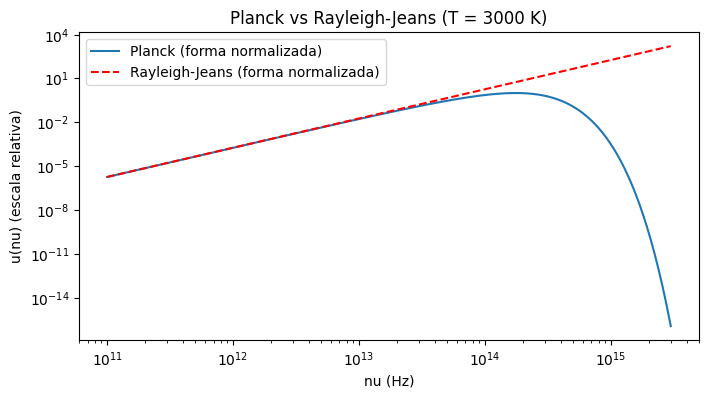

In [81]:
plt.figure(figsize=(8, 4))
plt.loglog(nu_grid, u_planck_n, label="Planck (forma normalizada)")
plt.loglog(nu_grid, u_rj_n, color='red', linestyle='--', label="Rayleigh-Jeans (forma normalizada)")
plt.xlabel("nu (Hz)")
plt.ylabel("u(nu) (escala relativa)")
plt.title("Planck vs Rayleigh-Jeans (T = 3000 K)")
plt.legend()
plt.show()

In [ ]:
print("En el régimen de bajas frecuencias, la curva de Planck y la de Rayleigh-Jeans se superponen.")
print("La energía se distribuye uniformemente siguiendo el teorema de equipartición.")
print("A medida que la frecuencia aumenta hacia el espectro ultravioleta, las curvas divergen.")
print("RJ predice una energía que tiende a infinito. Al introducir E=hf, la curva decae a cero.")

En el régimen de bajas frecuencias, la curva de Planck y la de Rayleigh-Jeans se superponen.
La energía se distribuye uniformemente siguiendo el teorema de equipartición.
A medida que la frecuencia aumenta hacia el espectro ultravioleta, las curvas divergen.
RJ predice una energía que tiende a infinito. Al introducir E=hf, la curva decae a cero.


## 2.1) (Optional) With the physical prefactor (cavity, SI) 

u_RJ(nu,T) = (8 pi nu^2/c^3) * kB T u_P(nu,T) = (8 pi h nu^3/c^3) / (exp(h nu)/(kB T) -1)

In [ ]:
T_spec = 3000.0
nu_grid = np.logspace(11, 15.5, 800)
u_RJ_SI = (8*np.pi*nu_grid**2/(c**3)) * (kB*T_spec)
u_P_SI = (8*np.pi*h*nu_grid**3/(c**3)) * (1.0/(np.exp(h*nu_grid/(kB*T_spec)) - 1.0))

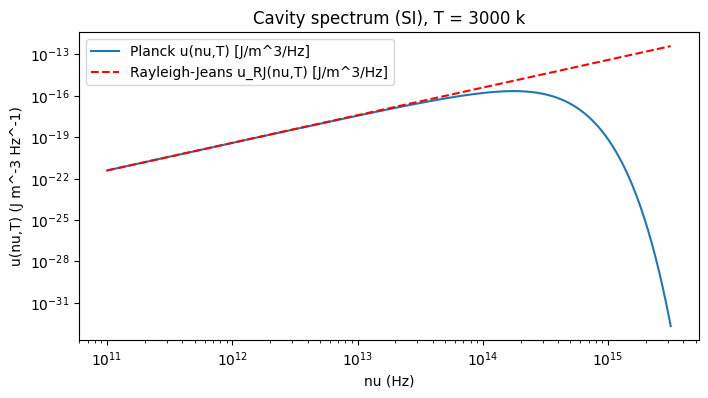

In [ ]:
plt.figure(figsize=(8, 4))
plt.loglog(nu_grid, u_P_SI, label="Planck u(nu,T) [J/m^3/Hz]")
plt.loglog(nu_grid, u_RJ_SI, color='red', linestyle='--', label="Rayleigh-Jeans u_RJ(nu,T) [J/m^3/Hz]")
plt.xlabel("nu (Hz)")
plt.ylabel("u(nu,T) (J m^-3 Hz^-1)")
plt.title("Cavity spectrum (SI), T = 3000 k")
plt.legend()
plt.show()

## 3) Spectral maximum and shift with T (Wien shift)

We find numerically the peak frequency $\nu_{\max}$ of $u_P(\nu, T)$ for two temperatures and compare the shift.


In [ ]:
def u_planck_SI(nu, T):
  x = (h*nu)/(kB*T)
  prefactor = (8*np.pi*h*nu**3)/(c**3)
  bose_factor = 1/(np.exp(x) - 1)
  return prefactor * bose_factor

def find_peak_nu(T, nu_min=1e11, nu_max=3e15, Npoints=1000):
  nu_grid = np.logspace(np.log10(nu_min), np.log10(nu_max), Npoints)
  u_vals = u_planck_SI(nu_grid, T)
  i_max = np.argmax(u_vals)
  return nu_grid[i_max], u_vals[i_max], nu_grid, u_vals

In [85]:
T1, T2 = 3000.0, 300.0
nu1, u1, grid1, spec1 = find_peak_nu(T1)
nu2, u2, grid2, spec2 = find_peak_nu(T2)

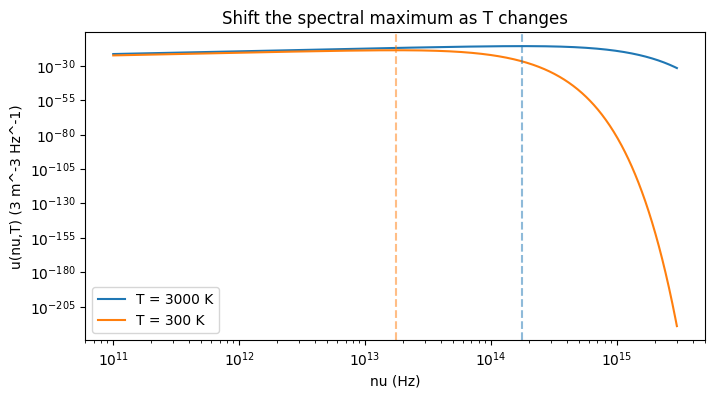

In [86]:
plt.figure(figsize=(8, 4))
plt.loglog(grid1, spec1, label=f"T = {T1:.0f} K", color="C0")
plt.loglog(grid2, spec2, label=f"T = {T2:.0f} K", color="C1")
plt.axvline(nu1, linestyle="--", color="C0", alpha=0.5)
plt.axvline(nu2, linestyle="--", color="C1", alpha=0.5)
plt.xlabel("nu (Hz)")
plt.ylabel("u(nu,T) (3 m^-3 Hz^-1)")
plt.title("Shift the spectral maximum as T changes")
plt.legend()
plt.show()

In [87]:
print(f"Maximum for T={T1:.0f} K: nu_max ~ {nu1:.3e} Hz")
print(f"Maximum for T={T2:.0f} K: nu_max ~ {nu2:.3e} Hz")

Maximum for T=3000 K: nu_max ~ 1.757e+14 Hz
Maximum for T=300 K: nu_max ~ 1.759e+13 Hz


La predicción clásica diverge a altas frecuencias pues al combinar ambos ingredientes, tenemos que la equipartición clásica asigna kB T a cada modo, y el número de modos nu² crece rápidamente. Así, tendiendo las frecuencias a infinito, la energía se comporta como kB T * nu². Esta energía diverge conforme nu² crece.

La cuantización de la energía se comporta como una distribución con decaimiento exponencial, es decir, para nu grandes P(n) tiende a 0. Así, al combinar los ingredientes, la energía se comporta como P(n) * nu², la cual tiende a 0.